## Семинар: "Методы оптимизации"

In [3]:
from functools import partial

import numpy as np
import torch
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib import animation
from mpl_toolkits import mplot3d
from matplotlib.gridspec import GridSpec
from torchvision import datasets, transforms
from IPython.display import HTML
%matplotlib inline
plt.rc('animation', html='html5')

На этом семинаре мы попробуем реализовать и сравнить различные методы оптимизации: SGD, Momentum, NAG, Adagrad, RMSProp, AdaDelta.

### Реализация методов

Для всех экспериментов подберите параметры так, чтобы метод сошелся к ближайшему локальному минимуму. Все методы следует запускать из одной и той же точки.

In [4]:
# https://github.com/dzlab/deepprojects/blob/master/visualization/Optimizers_in_Action.ipynb

def grid_samples(center=[0, 0], offset=5, size=100):
    range1 = np.linspace(center[0]-offset, center[0]+offset, size)
    range2 = np.linspace(center[1]-offset, center[1]+offset, size)
    return torch.from_numpy(np.stack(np.meshgrid(range1, range2))).float()


def mse(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1)


def msre(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1).sqrt()


def mae(y, y_hat):
    return ((y - y_hat).abs()).mean(axis=-1)


class LossAnimator:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.size = len(X)

    def loss_func(self, W, loss):
        shape = W.shape
        return loss((self.X @ W.view(shape[0], -1)).T, self.y).view(shape[1:])

    def plot_loss_funcs(self, weights, fcts, titles, view=(20, 50)):
        num_fcts = len(fcts)
        fig = plt.figure(figsize=(7 * num_fcts,7))
        for i in range(num_fcts):
            loss = self.loss_func(weights, loss=fcts[i])
            ax = fig.add_subplot(1, num_fcts, i+1, projection='3d')
            ax.plot_surface(*weights, loss, cmap='viridis')
            ax.set_xlabel('w0'); ax.set_ylabel('w1'); ax.set_zlabel('Loss')
            ax.set_title(titles[i])
            ax.view_init(*view)

    def _init_animation(self, epochs, train_data):
        self.train_data = train_data
        self.epochs = epochs
        self.nmethods = len(train_data)

        weights = grid_samples(offset=5)

        max_loss = max([data['losses'].max() for data in train_data.values()])
        loss_curve = self.loss_func(weights, loss=mse)
        colors = cm.rainbow(np.linspace(0, 1, self.nmethods))


        self.fig = plt.figure(figsize=(14, 8))
        self.gs = GridSpec(2, 2, width_ratios=[1, 2.5])

        self.ax0 = self.fig.add_subplot(self.gs[0,0])
        self.lines0 = {
            name: self.ax0.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax0.scatter(self.X[:,0], self.y, c='orange', label='Ground truth')
        self.ax0.set_ylim(self.y.min(), self.y.max())
        self.ax0.set_title('Ground truth & Model', fontsize=16)
        self.ax0.legend(loc='lower right')

        self.ax1 = self.fig.add_subplot(self.gs[:,1], projection='3d')
        self.ax1.plot_surface(*weights, loss_curve-0.5, cmap='viridis', alpha=0.8)
        self.ax1.view_init(50, 70)
        self.lines1 = {
            name: self.ax1.plot3D([], [], [], c=c, marker='o', alpha=0.9, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax1.set_title('Loss', fontsize=16, pad=20)
        self.ax1.set_xlabel('w0')
        self.ax1.set_ylabel('w1')
        self.ax1.set_zlabel('Loss')
        self.ax1.legend()

        self.ax2 = self.fig.add_subplot(self.gs[1,0])
        self.lines2 = {
            name: self.ax2.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax2.set_title('Loss', fontsize=16)
        self.ax2.set_ylabel('loss')
        self.ax2.set_ybound(0, max_loss)
        self.ax2.set_xlim(0, epochs)
        self.ax2.legend(loc='center right')

        self.fig.tight_layout()
        self.fig.subplots_adjust(top=0.85)

        plt.close()

        return self.fig

    def _animate(self, i):
        steps = np.arange(i+1)
        left = max(0, i-20)
        for name, data in self.train_data.items():
            # plot ground truth & model
            self.lines0[name].set_data(self.X[:, 0], self.X @ data['weights'][i])

            # plot loss (output of the sampling)
            self.lines1[name].set_data(data['weights'][left:i+1, 0], data['weights'][left:i+1, 1])
            self.lines1[name].set_3d_properties(data['losses'][left:i+1])

            self.lines2[name].set_data(steps, data['losses'][:i+1])

        self.fig.suptitle(f'Epoch: {i}/{self.epochs}', fontsize=22)

    def animate(self, epochs, train_data, step_skip=1):
        self._init_animation(epochs, train_data)
        anim = animation.FuncAnimation(self.fig, self._animate, frames=range(0, epochs, step_skip), interval=100 * step_skip)
        return HTML(anim.to_html5_video())

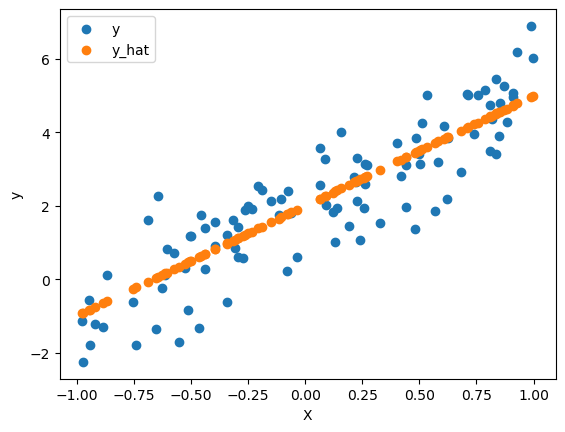

In [5]:
size = 100
X = torch.ones(size, 2)
X[:, 0].uniform_(-1., 1)

y_hat = 3 * X[:, 0] + 2
y = y_hat + torch.randn(size)

loss_animator = LossAnimator(X, y)

plt.scatter(loss_animator.X[:,0], loss_animator.y, label='y');
plt.scatter(loss_animator.X[:,0], y_hat, label='y_hat');
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

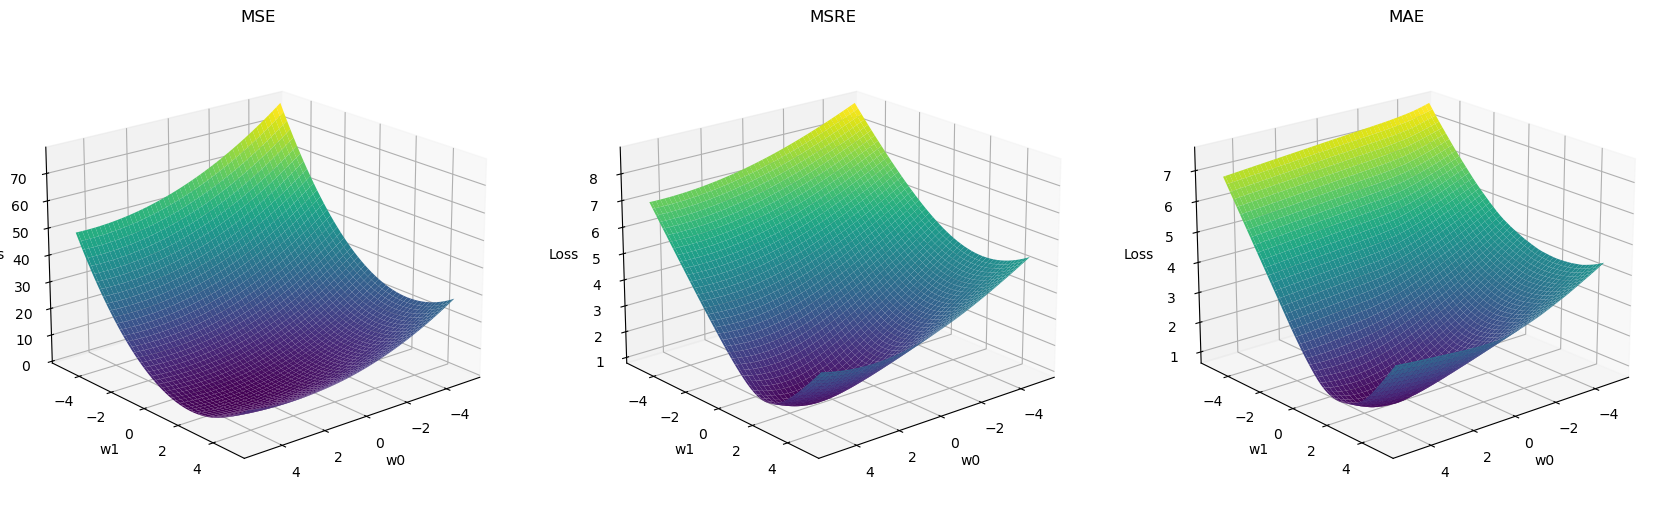

In [8]:
weights = grid_samples()
loss_animator.plot_loss_funcs(weights, [mse, msre, mae], ['MSE', 'MSRE', 'MAE'])
plt.show()

In [9]:
class Optimizer:
    def __init__(self, params):
        self.params = list(params)

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def pre_step(self):
        pass

    def step(self):
        pass

    def update_param(self, p):
        raise NotImplementedError()


In [10]:
def optimize_function(fn, optim, optim_args, start_point, num_iter = 50):
    weigths = nn.Parameter(torch.FloatTensor(start_point), requires_grad=True)

    optim = optim(params=[weigths], **optim_args)
    points = []
    losses = []
    for i in range(num_iter):
        if hasattr(optim, 'pre_step'):
            optim.pre_step()
        loss = fn(weigths)
        points.append(weigths.data.detach().clone())
        losses.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    points = torch.stack(points, axis=0)
    losses = torch.FloatTensor(losses)
    return points, losses


In [11]:
def compare_optimizers(
    loss_animator,
    fn,
    optim_list,
    start_point,
    num_iter = 50,
    step_skip = 1
):
    data = {}
    loss_func = partial(loss_animator.loss_func, loss=fn)
    for name, optim, args in tqdm(optim_list):
        points, losses = optimize_function(loss_func, optim, args, start_point, num_iter)
        data[name] = {
            'weights': points,
            'losses': losses,
        }

    return loss_animator.animate(num_iter, data, step_skip=step_skip)

#### SGD
$$\theta_t = \theta_{t-1} - \eta \sum_{i_1, ..., i_k} \nabla_{\theta} J_{i} (\theta_{t-1})$$

In [12]:
class SGD(Optimizer):
    def __init__(self, params, lr=1e-2):
        super().__init__(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                p -= self.lr * p.grad


#### Momentum
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [13]:
class Momentum(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= self.prev_momentum[i]

#### Nesterov Accelerated Gradient (NAG)
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1} - \gamma \nu_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [14]:
class NAG(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= (1 + self.gamma) * self.prev_momentum[i] - self.gamma * prev_momentum

#### AdaGrad
$$G_t = \sum_{k=0}^t g_{k}^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [15]:
class AdaGrad(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2):
        super().__init__(params)
        self.epsilon = epsilon
        self.eta = eta

        self.G = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.G[i] += p.grad ** 2
                p -= self.eta * p.grad / torch.sqrt(self.G[i] + self.epsilon)

#### RMSProp
$$G_t = \gamma G_{t-1} + (1 - \gamma) g_t^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [16]:
class RMSProp(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2, gamma=0.9):
        super().__init__(params)
        self.eta = eta
        self.epsilon = epsilon
        self.gamma = gamma

        self.G = [torch.zeros(p.shape) for p in self.params]


    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                self.G[i] = self.gamma * self.G[i] + (1 - self.gamma) * (p.grad ** 2)
                p -= self.eta / torch.sqrt(self.G[i] + self.epsilon) * p.grad

In [17]:
from functools import partial

points, losses = optimize_function(
    partial(loss_animator.loss_func, loss=mse),
    SGD,
     {'lr': 1e-2},
    start_point=[-4, -4],
    num_iter=100
)

In [18]:
compare_optimizers(
    loss_animator,
    mae,
    [
        ['SGD', SGD, {'lr': 1e-1}],
        ['Momentum', NAG, {'lr': 1e-1}],
        ['NAG', NAG, {'lr': 1e-1}],
        ['AdaGrad', AdaGrad, {'eta' : 1}],
        ['RMSProp', RMSProp, {'eta' : 1}],
    ],
    start_point=[-4, -4],
    num_iter=100
)

100%|██████████| 5/5 [00:00<00:00, 15.59it/s]


###  Домашнее задание: Обучение нейронной сети + Подбор шага

В этом задании вам нужно:
1) Реализовать Adam, AdamW и обучить сверточную нейросеть на MNIST. Сравнить графики обучения для SGD, Adam и AdamW. **(2 балла)**
2) Реализовать LinearLR и CosineAnnealingLR. Обучить сверточную нейросеть на MNIST с SGD, Adam, AdamW с LinearLR, CosineAnnealingLR. Сравните графики изменения loss-функции и точности (суммарно должно быть 9 экспериментов, 3 из которых покрываются пунктом 1). **(3 балла)**

Ссылки:
- https://arxiv.org/abs/1711.05101 (AdamW, статья)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html (AdamW, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html (LinearLR, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html (CosineAnnealingLR, PyTorch)

In [19]:
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [03:33<00:00, 46.4kB/s]


Extracting .\MNIST\raw\train-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 191kB/s]


Extracting .\MNIST\raw\train-labels-idx1-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:02<00:00, 712kB/s] 


Extracting .\MNIST\raw\t10k-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 552kB/s]

Extracting .\MNIST\raw\t10k-labels-idx1-ubyte.gz to .\MNIST\raw



Реализация оптимизатора Adam

In [48]:
class Adam(Optimizer):
    def __init__(self, params, lr=1e-4, beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        self.m = [torch.zeros(p.shape) for p in self.params]
        self.v = [torch.zeros(p.shape) for p in self.params]
        self.t = 0

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_m = self.m[i]
                prev_v = self.v[i]
                self.m[i] = self.beta1 * prev_m + (1 - self.beta1) * p.grad
                self.v[i] = self.beta2 * prev_v + (1 - self.beta2) * (p.grad ** 2)
                m_hat = self.m[i] / (1 - (self.beta1 ** self.t))
                v_hat = self.v[i] / (1 - (self.beta2 ** self.t))
                p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.epsilon)


Реализация оптимизатора AdamW

In [52]:
class AdamW(Optimizer):
    def __init__(
            self, 
            params, 
            lr=1e-4, 
            beta1=0.9, 
            beta2=0.999, 
            epsilon=1e-8,
            weight_decay=0.01
    ):
        super().__init__(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.weight_decay = weight_decay

        self.m = [torch.zeros(p.shape) for p in self.params]
        self.v = [torch.zeros(p.shape) for p in self.params]
        self.t = 0

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                p -= self.lr * self.weight_decay * p
                
                prev_m = self.m[i]
                prev_v = self.v[i]
                self.m[i] = self.beta1 * prev_m + (1 - self.beta1) * p.grad
                self.v[i] = self.beta2 * prev_v + (1 - self.beta2) * (p.grad ** 2)
                m_hat = self.m[i] / (1 - (self.beta1 ** self.t))
                v_hat = self.v[i] / (1 - (self.beta2 ** self.t))
                p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.epsilon)


Нейросеть

In [40]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self. net = nn.Sequential(
            # 1 x 28 x 28
            nn.Conv2d(1, 4, kernel_size=5),
            nn.ReLU(),
            # 4 x 24 x 24
            nn.MaxPool2d(kernel_size=2),
            # 4 x 12 x 12
            nn.Conv2d(4, 8, kernel_size=3),
            nn.ReLU(),
            # 8 x 10 x 10
            nn.Flatten(),
            nn.Linear(800, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, X):
        return self.net(X)
    
    def num_params(self):
        return sum(p.numel() for p in self.net.parameters())

количество параметров

In [41]:
net = Network()
net.num_params()

104218

процедура обучения

In [53]:
import typing as tt

def train(
        network,
        optimizer,
        objective,
        n_epochs=10,
        validate_every_iter=1
) -> tt.Tuple[tt.List[float], tt.List[float]]:
    loss_history = []
    accy_history = []
    for epoch in range(n_epochs):
        # обучение
        for x_train, y_train in tqdm(train_loader):
            optimizer.zero_grad()
            y_pred = network(x_train)
            loss = objective(y_pred, y_train)
            loss.backward()
            optimizer.step()
        # валидация
        if epoch % validate_every_iter == 0:
            curr_loss = []
            curr_accy = []
            with torch.no_grad():
                for x_val, y_val in tqdm(test_loader):
                    y_pred = network(x_val)
                    curr_loss.append(float(objective(y_pred, y_val).item()))
                    curr_accy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())
            loss = float(np.mean(curr_loss))
            accy = float(np.mean(curr_accy))
            print(f"Epoch: {epoch}, loss: {loss}, accuracy: {accy}")
            loss_history.append(loss)
            accy_history.append(accy)
    return loss_history, accy_history

обучение с помощью SGD

In [57]:
net = Network()
optimizer = SGD(net.parameters(), lr=0.01)
objective = nn.CrossEntropyLoss()
sgd_loss, sgd_accy = train(net, optimizer, objective)

100%|██████████| 313/313 [00:02<00:00, 150.00it/s]


Epoch: 0, loss: 0.1733502765772299, accuracy: 0.9507


100%|██████████| 313/313 [00:02<00:00, 152.70it/s]


Epoch: 1, loss: 0.10416977889553165, accuracy: 0.9678


100%|██████████| 313/313 [00:02<00:00, 152.61it/s]


...

Epoch: 7, loss: 0.054123273089947625, accuracy: 0.9836


100%|██████████| 313/313 [00:02<00:00, 141.20it/s]


Epoch: 8, loss: 0.05900904798293308, accuracy: 0.9803


100%|██████████| 313/313 [00:02<00:00, 128.87it/s]


Epoch: 9, loss: 0.05695271269476321, accuracy: 0.9824


Оптимизация с помощью Adam

In [58]:
net = Network()
optimizer = Adam(net.parameters(), lr=0.001)
objective = nn.CrossEntropyLoss()
adam_loss, adam_accy = train(net, optimizer, objective)

100%|██████████| 313/313 [00:02<00:00, 147.95it/s]


Epoch: 0, loss: 0.07928573756408804, accuracy: 0.9746


100%|██████████| 313/313 [00:02<00:00, 148.14it/s]


Epoch: 1, loss: 0.04611403251530977, accuracy: 0.9853


100%|██████████| 313/313 [00:02<00:00, 146.72it/s]


...

Epoch: 7, loss: 0.043291838288484014, accuracy: 0.9886


100%|██████████| 313/313 [00:02<00:00, 145.79it/s]


Epoch: 8, loss: 0.04995371583666851, accuracy: 0.987


100%|██████████| 313/313 [00:02<00:00, 146.74it/s]

Epoch: 9, loss: 0.05141391142706924, accuracy: 0.9877


Оптимизация AdamW

In [59]:
net = Network()
optimizer = AdamW(net.parameters(), lr=0.001)
objective = nn.CrossEntropyLoss()
adamw_loss, adamw_accy = train(net, optimizer, objective)

100%|██████████| 313/313 [00:02<00:00, 151.46it/s]


Epoch: 0, loss: 0.0638860049486434, accuracy: 0.9802


100%|██████████| 313/313 [00:02<00:00, 136.02it/s]


Epoch: 1, loss: 0.05339200948826231, accuracy: 0.9826


100%|██████████| 313/313 [00:02<00:00, 145.76it/s]


...

Epoch: 7, loss: 0.04929847961297761, accuracy: 0.9861


100%|██████████| 313/313 [00:02<00:00, 149.23it/s]


Epoch: 8, loss: 0.05409364895318361, accuracy: 0.987


100%|██████████| 313/313 [00:02<00:00, 147.49it/s]

Epoch: 9, loss: 0.04758205357424109, accuracy: 0.9869


сравним графики лосса и точности

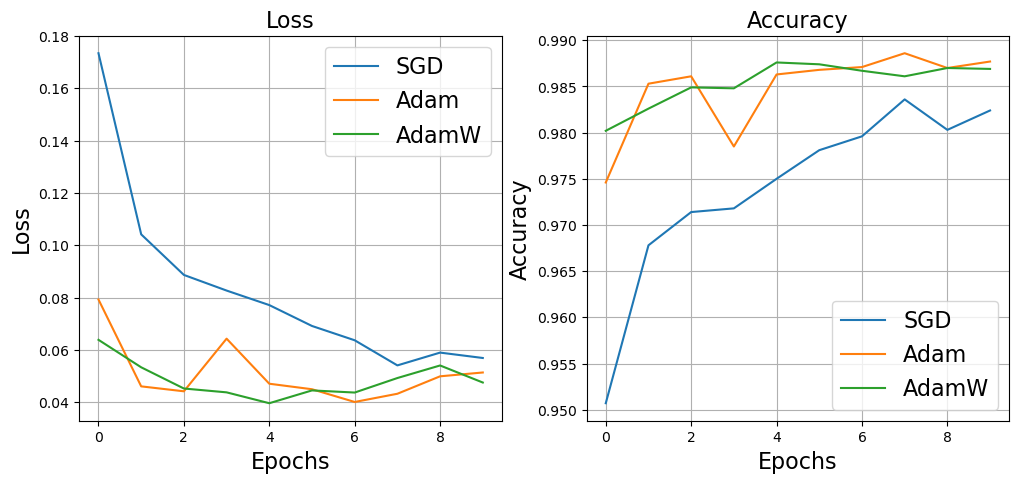

In [60]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Loss", fontsize=16)
plt.plot(sgd_loss, label="SGD")
plt.plot(adam_loss, label="Adam")
plt.plot(adamw_loss, label="AdamW")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Accuracy", fontsize=16)
plt.plot(sgd_accy, label="SGD")
plt.plot(adam_accy, label="Adam")
plt.plot(adamw_accy, label="AdamW")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.show()

Сразу можно замеить, что SGD сходился медленнее всех. Да и всё равно как и конечный лосс, так и конечная точность лучше у Adam и AdamW. По данным графикам таке можно заметить, что у AdamW более гладкаая кривая лосса, в отличие от Adam. 

2 задание

In [61]:
class LRScheduler:
    def __init__(self, optimizer: Optimizer):
        self.optimizer = optimizer

    def step(self):
        pass

Реализация LinearLR и CosineAnnealing

In [81]:
class LinearLR(LRScheduler):
    def __init__(
        self,
        optimizer: Optimizer,
        start_factor: float = 0.1,
        end_factor: float = 1.0,
        total_iters: int = 100
    ):
        super().__init__(optimizer)
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_iters = total_iters
        self.step_factor = (end_factor - start_factor) / total_iters
        self.iter_no = 0
        self.actual_lr = self.optimizer.lr

    def step(self):
        self.iter_no += 1
        if self.iter_no <= self.total_iters:
            next_lr = (self.start_factor + self.step_factor * self.iter_no) * self.actual_lr
            self.optimizer.lr = next_lr
        

class CosineAnnealing(LRScheduler):
    def __init__(
            self,
            optimizer: Optimizer,
            T_max: int = 20,
            eta_min: float = 0.01
        ):
        super().__init__(optimizer)
        self.T_max = T_max
        self.eta_min = eta_min
        self.T_current = 0
        self.eta_max = self.optimizer.lr

    def step(self):
        next_eta = self.eta_min + 0.5 * (self.eta_max - self.eta_min) * \
            (1 + torch.cos(torch.tensor(self.T_current / self.T_max * torch.pi, dtype=torch.float32)))
        self.optimizer.lr = next_eta.item()
        self.T_current += 1
        

Теперь проведём экcперименты

In [82]:
import typing as tt

def scheduled_train(
        network,
        optimizer,
        scheduler,
        objective,
        n_epochs=10,
        validate_every_iter=1
) -> tt.Tuple[tt.List[float], tt.List[float]]:
    loss_history = []
    accy_history = []
    for epoch in range(n_epochs):
        # обучение
        for x_train, y_train in tqdm(train_loader):
            optimizer.zero_grad()
            y_pred = network(x_train)
            loss = objective(y_pred, y_train)
            loss.backward()
            optimizer.step()
            scheduler.step()
        # валидация
        if epoch % validate_every_iter == 0:
            curr_loss = []
            curr_accy = []
            with torch.no_grad():
                for x_val, y_val in tqdm(test_loader):
                    y_pred = network(x_val)
                    curr_loss.append(float(objective(y_pred, y_val).item()))
                    curr_accy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())
            loss = float(np.mean(curr_loss))
            accy = float(np.mean(curr_accy))
            print(f"Epoch: {epoch}, loss: {loss}, accuracy: {accy}")
            loss_history.append(loss)
            accy_history.append(accy)
    return loss_history, accy_history

## LinearLR

SGD

In [83]:
net = Network()
optimizer = SGD(net.parameters(), lr=0.01)
scheduler = LinearLR(optimizer, total_iters=7)
objective = nn.CrossEntropyLoss()
lin_sgd_loss, lin_sgd_accy = scheduled_train(net, optimizer, scheduler, objective)

100%|██████████| 313/313 [00:02<00:00, 129.42it/s]


Epoch: 0, loss: 0.14626343040682446, accuracy: 0.9552


100%|██████████| 313/313 [00:02<00:00, 148.10it/s]


Epoch: 1, loss: 0.09351511910474433, accuracy: 0.9721


100%|██████████| 313/313 [00:02<00:00, 131.48it/s]


...

Epoch: 7, loss: 0.044971496185429914, accuracy: 0.9849


100%|██████████| 313/313 [00:02<00:00, 146.33it/s]


Epoch: 8, loss: 0.04235326038990036, accuracy: 0.987


100%|██████████| 313/313 [00:02<00:00, 148.35it/s]

Epoch: 9, loss: 0.04183015699078814, accuracy: 0.986


Adam

In [84]:
net = Network()
optimizer = Adam(net.parameters(), lr=0.001)
scheduler = LinearLR(optimizer, total_iters=7)
objective = nn.CrossEntropyLoss()
lin_adam_loss, lin_adam_accy = scheduled_train(net, optimizer, scheduler, objective)

100%|██████████| 313/313 [00:02<00:00, 147.97it/s]


Epoch: 0, loss: 0.06326491363828603, accuracy: 0.9801


100%|██████████| 313/313 [00:02<00:00, 146.90it/s]


Epoch: 1, loss: 0.05159518555009041, accuracy: 0.9845


100%|██████████| 313/313 [00:02<00:00, 147.94it/s]


...

Epoch: 7, loss: 0.04421429899503127, accuracy: 0.988


100%|██████████| 313/313 [00:02<00:00, 146.73it/s]


Epoch: 8, loss: 0.05567079639245922, accuracy: 0.9868


100%|██████████| 313/313 [00:02<00:00, 149.67it/s]

Epoch: 9, loss: 0.04262876958564782, accuracy: 0.9885


AdamW

In [85]:
net = Network()
optimizer = AdamW(net.parameters(), lr=0.001)
scheduler = LinearLR(optimizer, total_iters=7)
objective = nn.CrossEntropyLoss()
lin_adamw_loss, lin_adamw_accy = scheduled_train(net, optimizer, scheduler, objective)

100%|██████████| 313/313 [00:02<00:00, 140.69it/s]


Epoch: 0, loss: 0.06451304909139395, accuracy: 0.9803


100%|██████████| 313/313 [00:02<00:00, 145.82it/s]


Epoch: 1, loss: 0.04739923830465458, accuracy: 0.9864


100%|██████████| 313/313 [00:02<00:00, 146.01it/s]


...

Epoch: 7, loss: 0.04800447685212099, accuracy: 0.9868


100%|██████████| 313/313 [00:02<00:00, 141.52it/s]


Epoch: 8, loss: 0.04406028068795643, accuracy: 0.9891


100%|██████████| 313/313 [00:02<00:00, 149.32it/s]

Epoch: 9, loss: 0.05760719339091905, accuracy: 0.9848


## CosineAnnealing

SGD

In [86]:
net = Network()
optimizer = SGD(net.parameters(), lr=0.01)
scheduler = CosineAnnealing(optimizer, T_max=5, eta_min=0.001)
objective = nn.CrossEntropyLoss()
cos_sgd_loss, cos_sgd_accy = scheduled_train(net, optimizer, scheduler, objective)

100%|██████████| 313/313 [00:02<00:00, 146.07it/s]


Epoch: 0, loss: 0.2059387011816517, accuracy: 0.9401


100%|██████████| 313/313 [00:02<00:00, 145.40it/s]


Epoch: 1, loss: 0.12231494911824362, accuracy: 0.9613


100%|██████████| 313/313 [00:02<00:00, 146.96it/s]


...

Epoch: 7, loss: 0.05153546815242666, accuracy: 0.9834


100%|██████████| 313/313 [00:02<00:00, 148.34it/s]


Epoch: 8, loss: 0.0523792142803504, accuracy: 0.9837


100%|██████████| 313/313 [00:02<00:00, 145.64it/s]

Epoch: 9, loss: 0.0485732952927272, accuracy: 0.9849


Adam

In [87]:
net = Network()
optimizer = Adam(net.parameters(), lr=0.001)
scheduler = CosineAnnealing(optimizer, T_max=5, eta_min=0.0001)
objective = nn.CrossEntropyLoss()
cos_adam_loss, cos_adam_accy = scheduled_train(net, optimizer, scheduler, objective)

100%|██████████| 313/313 [00:02<00:00, 146.26it/s]


Epoch: 0, loss: 0.0754638668075323, accuracy: 0.9754


100%|██████████| 313/313 [00:02<00:00, 150.26it/s]


Epoch: 1, loss: 0.05605516020623676, accuracy: 0.9824


100%|██████████| 313/313 [00:02<00:00, 152.67it/s]


...

Epoch: 7, loss: 0.036452508111126686, accuracy: 0.9889


100%|██████████| 313/313 [00:02<00:00, 148.12it/s]


Epoch: 8, loss: 0.04688216672776542, accuracy: 0.9853


100%|██████████| 313/313 [00:02<00:00, 149.80it/s]

Epoch: 9, loss: 0.04236477740181226, accuracy: 0.9869


AdamW

In [88]:
net = Network()
optimizer = AdamW(net.parameters(), lr=0.001)
scheduler = CosineAnnealing(optimizer, T_max=5, eta_min=0.0001)
objective = nn.CrossEntropyLoss()
cos_adamw_loss, cos_adamw_accy = scheduled_train(net, optimizer, scheduler, objective)

100%|██████████| 313/313 [00:02<00:00, 149.04it/s]


Epoch: 0, loss: 0.07660552924766709, accuracy: 0.975


100%|██████████| 313/313 [00:02<00:00, 149.06it/s]


Epoch: 1, loss: 0.048877011388376614, accuracy: 0.9847


100%|██████████| 313/313 [00:02<00:00, 145.95it/s]


...

Epoch: 7, loss: 0.043012915474262996, accuracy: 0.9885


100%|██████████| 313/313 [00:02<00:00, 148.89it/s]


Epoch: 8, loss: 0.039396552777431385, accuracy: 0.9883


100%|██████████| 313/313 [00:02<00:00, 151.26it/s]

Epoch: 9, loss: 0.03685631225063623, accuracy: 0.9894


функция для графиков

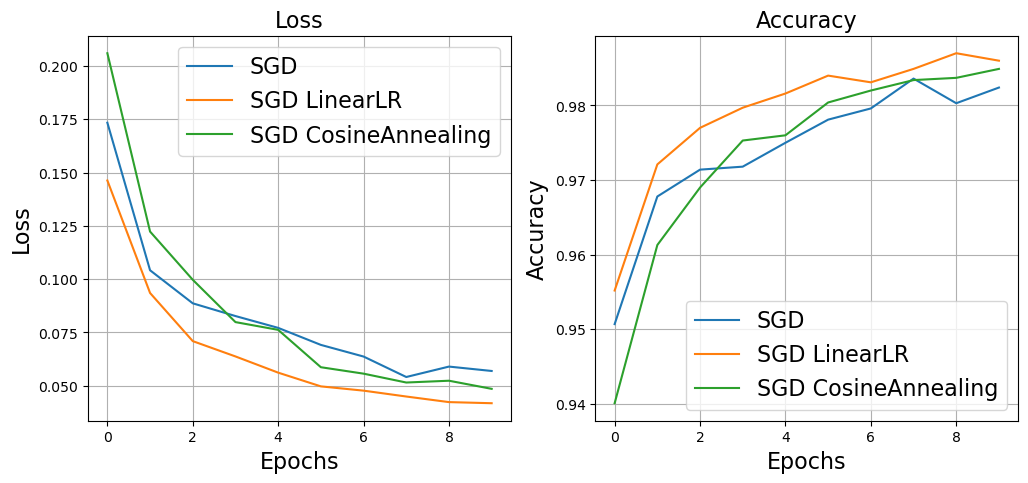

In [89]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Loss", fontsize=16)
plt.plot(sgd_loss, label="SGD")
plt.plot(lin_sgd_loss, label="SGD LinearLR")
plt.plot(cos_sgd_loss, label="SGD CosineAnnealing")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Accuracy", fontsize=16)
plt.plot(sgd_accy, label="SGD")
plt.plot(lin_sgd_accy, label="SGD LinearLR")
plt.plot(cos_sgd_accy, label="SGD CosineAnnealing")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.show()

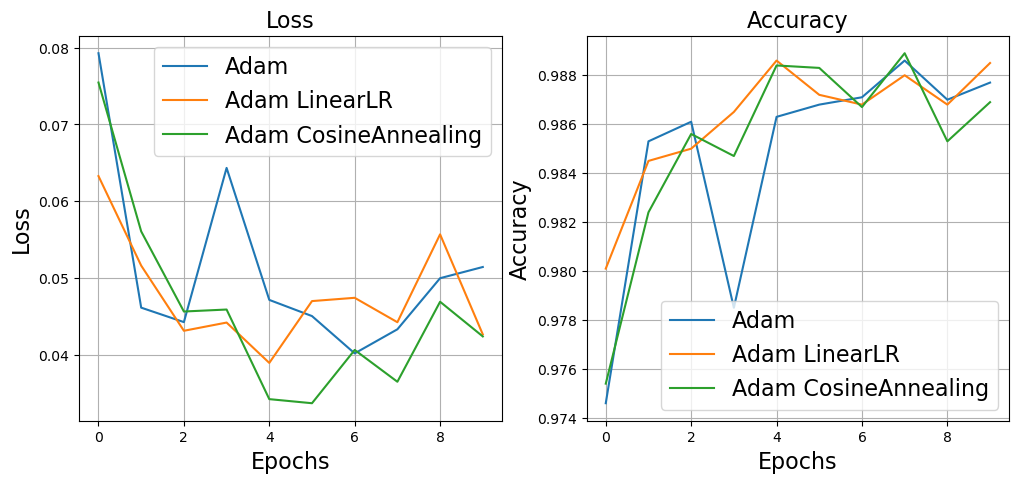

In [90]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Loss", fontsize=16)
plt.plot(adam_loss, label="Adam")
plt.plot(lin_adam_loss, label="Adam LinearLR")
plt.plot(cos_adam_loss, label="Adam CosineAnnealing")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Accuracy", fontsize=16)
plt.plot(adam_accy, label="Adam")
plt.plot(lin_adam_accy, label="Adam LinearLR")
plt.plot(cos_adam_accy, label="Adam CosineAnnealing")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.show()

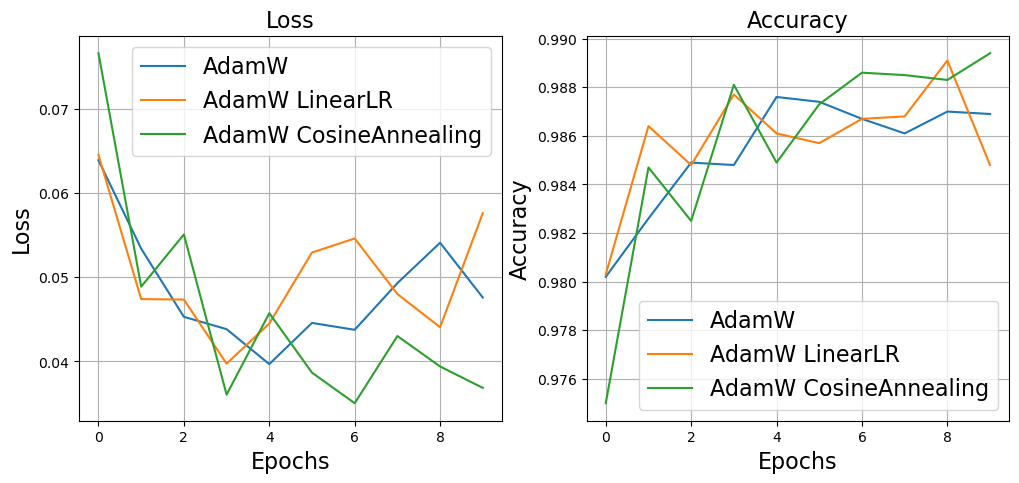

In [91]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Loss", fontsize=16)
plt.plot(adamw_loss, label="AdamW")
plt.plot(lin_adamw_loss, label="AdamW LinearLR")
plt.plot(cos_adamw_loss, label="AdamW CosineAnnealing")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Accuracy", fontsize=16)
plt.plot(adamw_accy, label="AdamW")
plt.plot(lin_adamw_accy, label="AdamW LinearLR")
plt.plot(cos_adamw_accy, label="AdamW CosineAnnealing")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()

plt.show()

на SGD очень хорошо видно, что шедулер позволяет получить более лучшее качество. На Adam и AdamW улучшение почти незаметно. Хотя возможно на большем количестве эпох эффект будет заметнее.

#### Feedback (опционально)

Здесь вы можете оставить список опечаток из лекции или семинара:

- Your text here

Здесь вы можете оставить комментарии по лекции или семинару:

- Your text here